# Support Materials

<span style="text-transform: uppercase;
        font-size: 14px;
        letter-spacing: 1px;
        font-family: 'Segoe UI', sans-serif;">
    Author
</span><br>
efrén cruz cortés
<hr style="border: none; height: 1px; background: linear-gradient(to right, transparent 0%, #ccc 10%, transparent 100%); margin-top: 10px;">

In [55]:
from pathlib import Path
import pandas as pd
import numpy as np
import random

from sklearn import datasets
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import svm
from sklearn.preprocessing import Normalizer

import matplotlib.pyplot as plt
import seaborn as sns

## Standardized vs non-standardized data

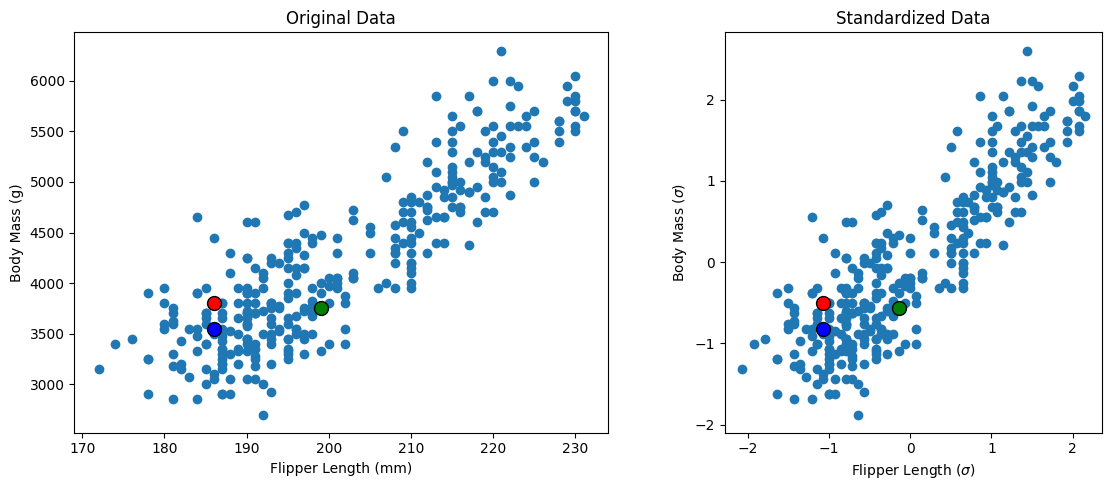

In [2]:
penguins_df = pd.read_csv("data/penguins.csv")

# Pick variables to visualize
var1 = 'flipper_length_mm'
var2 = 'body_mass_g'
penguins_df[[var1, var2]].head()

# Pick sample points to track in our visualization
sample_idx = [1, 50, 100]
sample_colors = ['red', 'blue', 'green']
sample_points = [np.array([penguins_df[var1].iloc[idx], penguins_df[var2].iloc[idx]]) for idx in sample_idx]

# Standardize data
z_scaler = preprocessing.StandardScaler()
z_scaler.fit(penguins_df[[var1, var2]])
z = z_scaler.transform(penguins_df[[var1, var2]])

# Plot the original and standardized data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(penguins_df[var1], penguins_df[var2])
ax2.scatter(z[:,0], z[:, 1])

# Add some sample points for comparison
for idx, color, (px, py) in zip(sample_idx, sample_colors, sample_points):
    ax1.scatter(px, py, color=color, s=100, edgecolors='black')
    ax2.scatter(z[idx, 0], z[idx, 1], color=color, s=100, edgecolors='black')

# Some aesthetics:
ax1.set(
    xlabel = 'Flipper Length (mm)',
    ylabel = 'Body Mass (g)',
    title = 'Original Data',
)
ax2.set(
    xlabel = 'Flipper Length ($\sigma$)',
    ylabel = 'Body Mass ($\sigma$)',
    title = 'Standardized Data',
    aspect= 'equal'
)

fig.tight_layout()

## Classification Visualization

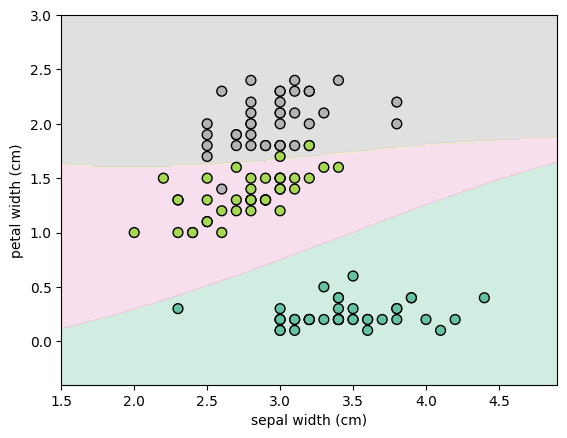

In [4]:
# Let's use iris
iris = datasets.load_iris()
iris.feature_names

# You can choose which two features to keep, I'll pick the widths
iris_feats = [1,3]
iris_X = iris.data[:,iris_feats]

# create the classifier
irisx_train, irisx_test, irisy_train, irisy_test = train_test_split(iris_X, iris.target, test_size=.2)
iris_clf = svm.SVC().fit(irisx_train, irisy_train)

# create the plane coordinates based on the observed values
grid_size = 300
s1_axis = np.linspace(iris_X[:,0].min() - .5, iris_X[:,0].max() + .5, num=grid_size)
s2_axis = np.linspace(iris_X[:,1].min() - .5, iris_X[:,1].max() + .5, num=grid_size)
ss1, ss2 = np.meshgrid(s1_axis, s2_axis)
grid = np.c_[ss1.ravel(), ss2.ravel()]

# Evaluate your classifier on all coordinate points
Z = iris_clf.predict(grid).reshape(ss1.shape)

# Plot class predictions over all space
plt.contourf(ss1, ss2, Z, alpha=.6, cmap='Pastel2')
plt.scatter(irisx_train[:, 0], irisx_train[:, 1], c=irisy_train, cmap='Set2', edgecolor='k', s=50)
plt.xlabel(iris.feature_names[iris_feats[0]])
plt.ylabel(iris.feature_names[iris_feats[1]])
plt.show()

## Imbalanced Set - Wine (Italy)
Create Imbalance set from wine

In [ ]:
# Step 1: Load the data
wine = datasets.load_wine(as_frame=True)
wine_df = wine.frame

# Step 2: Drop third class
wine_df = wine_df[wine_df['target'].isin([0,1])]

# Step 3: Subsample the second class
downsample_n = 10
class_0 = wine_df[wine_df['target'] == 0]
class_1 = wine_df[wine_df['target'] == 1].sample(n=downsample_n)

# Step 4: Make mock data
imbalanced_df = pd.concat([class_0, class_1], ignore_index=True)
X_imb = imbalanced_df.drop(columns='target')
y_imb = imbalanced_df['target']

save_yn = 0
if save_yn:
    imbalanced_df.to_csv(f'data/imbalanced_wine_{downsample_n}.csv', index=False)

## (Binary Classification) Portuguese Wine

In [ ]:
red_wine = pd.read_csv('data/wine_quality/winequality-red.csv', sep=';')
quality_threshold = 7
red_wine['quality'] = (red_wine['quality'] >= quality_threshold).astype(int)
save_wine_bin = 0
if save_wine_bin:
    red_wine.to_csv('data/red_wine_binary.csv', index=False)

## (Binary Classification) Portuguese Wine - Imbalanced

In [ ]:
red_wine = pd.read_csv('data/wine_quality/winequality-red.csv', sep=';')
high_quality_threshold = 8
red_wine['quality'] = (red_wine['quality'] >= high_quality_threshold).astype(int)
save_wine_bin = 0
if save_wine_bin:
    red_wine.to_csv('data/red_wine_binary_imbalanced.csv', index=False)

## Cross-validation visual examples

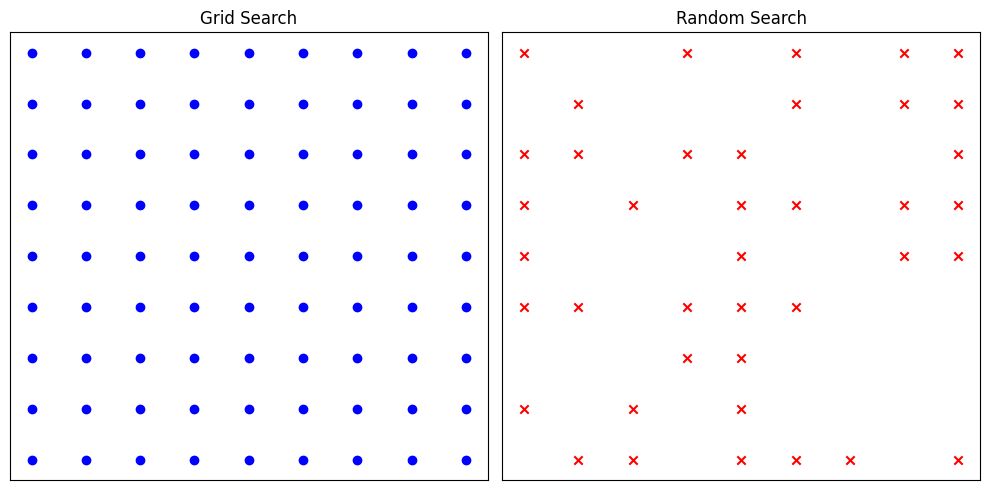

In [34]:
# hyperparameter grid vs random
H1 = list(range(1, 10)) # First hyperparamter values
H2 = list(range(1, 10))

grid_points = [(h1, h2) for h1 in H1 for h2 in H2] # full grid
num_random_points = 40
random_points = random.sample(grid_points, num_random_points) # random sample from grid points

# plot
grid_x, grid_y = zip(*grid_points)
rand_x, rand_y = zip(*random_points)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# Grid plot
axs[0].scatter(grid_x, grid_y, c='blue', marker='o')
axs[0].set_title("Grid Search")
axs[0].set_xticks([])
axs[0].set_yticks([])
# Random search plot
axs[1].scatter(rand_x, rand_y, c='red', marker='x')
axs[1].set_title('Random Search')
axs[1].set_yticks([])
axs[1].set_xticks([])

plt.tight_layout()
plt.show()

## Export Datasets (Wine and Diabetes)

Export the full 3-class UCI Wine Recognition dataset and Diabetes dataset to the `data/` folder using pandas."

In [3]:
# ==============================================================================
# :: DATASET GENERATION (Wine & Diabetes) ::
# ==============================================================================

data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

# 1. Full Wine Recognition dataset (Italy, UCI 3-class: 178 rows x 13 features + target)
wine = datasets.load_wine(as_frame=True)
wine_df = wine.frame
save_wine = 1
if save_wine:
    wine_df.to_csv(data_dir / "wine.csv", index=False)
    print(f"Saved {data_dir / 'wine.csv'} with shape {wine_df.shape}")

# 2. Full Diabetes dataset (442 rows x 10 features + target)
diabetes = datasets.load_diabetes(as_frame=True)
diabetes_df = diabetes.frame
save_diabetes = 1
if save_diabetes:
    diabetes_df.to_csv(data_dir / "diabetes.csv", index=False)
    print(f"Saved {data_dir / 'diabetes.csv'} with shape {diabetes_df.shape}")

Saved data/wine.csv with shape (178, 14)
Saved data/diabetes.csv with shape (442, 11)


## Prepare 20newsgroups data

In [32]:
# fetch the data

seed = 2026
n_news = 25
news_categories = ["sci.space", "sci.med", "rec.sport.baseball"]
min_post_length = 50
max_word_features = 30

news_data = datasets.fetch_20newsgroups(
    subset="train",
    categories=news_categories,
    remove=("headers", "footers", "quotes"),
    random_state=seed,
)

In [33]:
# subsample

news_df = pd.DataFrame({
    "text": news_data.data,
    "topic": [news_data.target_names[i] for i in news_data.target]
})
news_df = news_df[news_df["text"].str.strip().str.len() > min_post_length]  # remove small posts
news_df_sample = news_df.sample(n=n_news, random_state=seed).reset_index(drop=True)

In [ ]:
# vectorize

count_vectorizer = CountVectorizer(stop_words="english", max_features=max_word_features)
news_X_counts = count_vectorizer.fit_transform(news_df_sample["text"])

news_df_vectorized = pd.DataFrame(news_X_counts.toarray(), columns=count_vectorizer.get_feature_names_out())
news_df_vectorized.insert(0, "topic", news_df_sample["topic"])

In [35]:
news_df_vectorized

,topic,bad,best,better,chiggers,doesn,don,food,game,good,...,really,software,stance,things,think,time,ve,work,year,years
0,rec.sport.baseball,1,1,2,0,2,0,0,4,0,...,0,0,0,1,0,0,0,0,2,0
1,rec.sport.baseball,1,1,5,0,3,2,0,0,2,...,2,0,0,0,1,0,0,0,5,0
2,sci.med,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,rec.sport.baseball,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,rec.sport.baseball,1,0,0,0,0,2,0,1,2,...,1,0,6,0,1,0,1,0,0,1
5,sci.space,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,sci.med,0,0,0,0,0,0,9,0,0,...,0,0,0,0,0,0,0,0,0,0
7,sci.med,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
8,sci.med,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,sci.med,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# save

news_df_sample.to_csv("data/newsgroup_text_sample.csv", index=False)
news_df_vectorized.to_csv("data/newsgroup_vectorized_sample.csv", index=False)

## Prepare Fake text data

i realized the 20news was not as interesting when visualized as doing it manually

In [80]:
# load data
fake_text_df = pd.read_csv("data/fake_text_data.csv")

# vectorize
vocab = ["ball", "avocado"]
text_vectorizer = CountVectorizer(vocabulary=vocab)
fake_text_X_counts = text_vectorizer.fit_transform(fake_text_df["text"])

fake_text_df_vectorized = pd.DataFrame(
    fake_text_X_counts.toarray(),
    columns=text_vectorizer.get_feature_names_out()
)
fake_text_df_vectorized.insert(0, "topic", fake_text_df["topic"].to_numpy())

fake_text_df_vectorized.to_csv('data/fake_text_data_vectorized.csv', index=False)

### Visualizing word vectors

In [71]:
# Check which words define which topics
top_n = 5
word_topic_means = fake_text_df_vectorized.groupby("topic").mean().T

for topic_idx in range(len(fake_text_df['topic'].unique())):
    print(word_topic_means.sort_values(by=word_topic_means.columns[topic_idx], ascending=False).head(top_n), "\n")

topic    cooking  sports
avocado      2.4     0.8
ball         1.2     2.4
player       0.0     0.0
cook         0.0     0.0 

topic    cooking  sports
ball         1.2     2.4
avocado      2.4     0.8
player       0.0     0.0
cook         0.0     0.0 



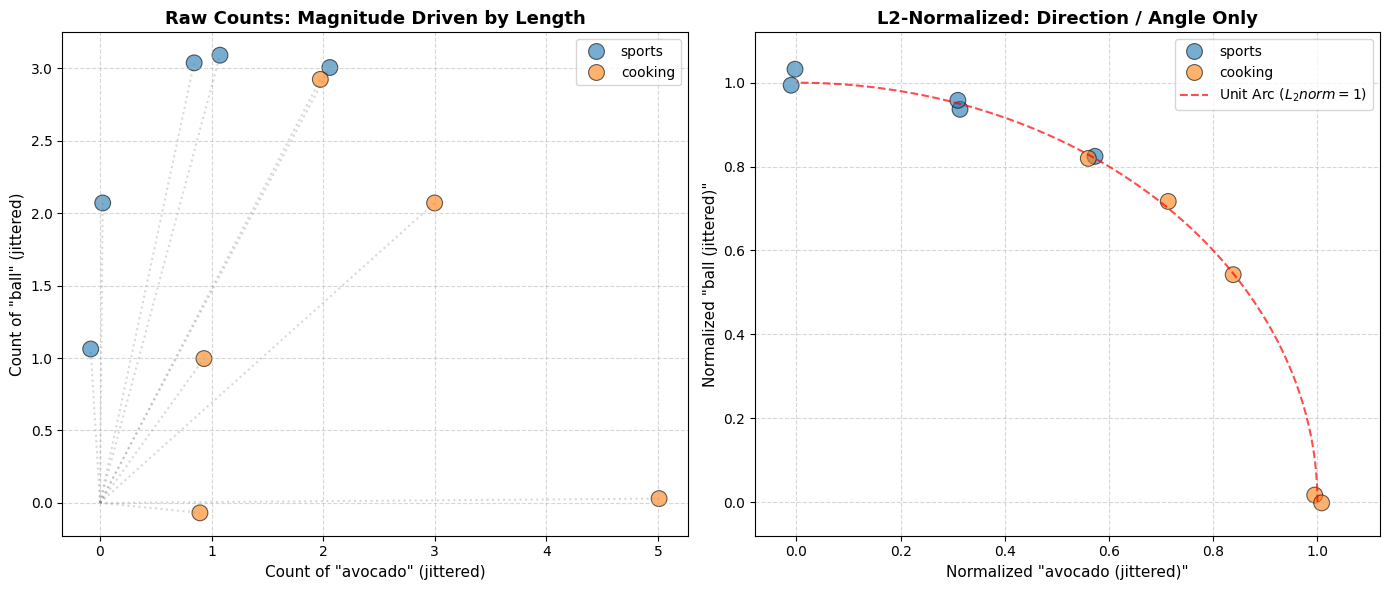

In [78]:
# 1. Select words and slice features
w1, w2 = "avocado", "ball"
sub_df = fake_text_df_vectorized[(fake_text_df_vectorized[w1] > 0) | (fake_text_df_vectorized[w2] > 0)].copy()

X_2d = sub_df[[w1, w2]].values.astype(float)
topics = sub_df["topic"].values

# 2. Row-wise L2 Normalization
normalizer = Normalizer(norm="l2")
X_norm_2d = normalizer.fit_transform(X_2d)

# 3. Add jitter (small uniform or normal noise)
rng = np.random.default_rng(seed=42)

# Small jitter for integer counts
raw_jitter_x = X_2d[:, 0] + rng.normal(0, 0.08, size=len(X_2d))
raw_jitter_y = X_2d[:, 1] + rng.normal(0, 0.08, size=len(X_2d))

# Tiny angular/radial jitter for normalized points to avoid ruining the arc shape
norm_jitter_x = X_norm_2d[:, 0] + rng.normal(0, 0.015, size=len(X_norm_2d))
norm_jitter_y = X_norm_2d[:, 1] + rng.normal(0, 0.015, size=len(X_norm_2d))

# 4. Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = {
    "sports": "#1f77b4",
    "cooking": "#ff7f0e",
}

# Left: Raw Counts with Jitter & Transparency
ax1 = axes[0]
sns.scatterplot(
    x=raw_jitter_x,
    y=raw_jitter_y,
    hue=topics,
    palette=palette,
    s=130,
    alpha=0.6,  # <-- Transparency (0.0 fully clear to 1.0 fully opaque)
    edgecolor="black",
    linewidth=0.8,
    ax=ax1,
)

for x_pt, y_pt in zip(raw_jitter_x, raw_jitter_y):
  ax1.plot(
      [0, x_pt], [0, y_pt], color="gray", linestyle=":", alpha=0.3, zorder=0
  )

ax1.set_title(
    "Raw Counts: Magnitude Driven by Length", fontsize=13, weight="bold"
)
ax1.set_xlabel(f'Count of "{w1}" (jittered)', fontsize=11)
ax1.set_ylabel(f'Count of "{w2}" (jittered)', fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.5)

# Right: Normalized with Jitter & Transparency
ax2 = axes[1]
sns.scatterplot(
    x=norm_jitter_x,
    y=norm_jitter_y,
    hue=topics,
    palette=palette,
    s=130,
    alpha=0.6,  # <-- Transparency
    edgecolor="black",
    linewidth=0.8,
    ax=ax2,
)

theta = np.linspace(0, np.pi / 2, 200)
ax2.plot(
    np.cos(theta),
    np.sin(theta),
    "r--",
    linewidth=1.5,
    alpha=0.7,
    label="Unit Arc ($L_2 norm = 1$)",
)

ax2.set_title(
    "L2-Normalized: Direction / Angle Only", fontsize=13, weight="bold"
)
ax2.set_xlabel(f'Normalized "{w1} (jittered)"', fontsize=11)
ax2.set_ylabel(f'Normalized "{w2} (jittered)"', fontsize=11)
ax2.set_xlim(-0.08, 1.12)
ax2.set_ylim(-0.08, 1.12)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [77]:
# -------------------------------------------------------------
# 1. Standalone Plot: Raw Counts
# -------------------------------------------------------------
fig_raw, ax_raw = plt.subplots(figsize=(7, 6))

sns.scatterplot(
    x=raw_jitter_x,
    y=raw_jitter_y,
    hue=topics,
    palette=palette,
    s=130,
    alpha=0.6,
    edgecolor="black",
    linewidth=0.8,
    ax=ax_raw,
)

for x_pt, y_pt in zip(raw_jitter_x, raw_jitter_y):
  ax_raw.plot(
      [0, x_pt], [0, y_pt], color="gray", linestyle=":", alpha=0.3, zorder=0
  )

ax_raw.set_title(
    "Raw Counts: Magnitude Driven by Length", fontsize=12, weight="bold"
)
ax_raw.set_xlabel(f'Count of "{w1}" (jittered)', fontsize=11)
ax_raw.set_ylabel(f'Count of "{w2}" (jittered)', fontsize=11)
ax_raw.grid(True, linestyle="--", alpha=0.5)

fig_raw.savefig(
    "images/vector_text_raw.png", dpi=300, bbox_inches="tight"
)
plt.close(fig_raw)  # Closes to free memory without displaying in notebook


# -------------------------------------------------------------
# 2. Standalone Plot: L2 Normalized
# -------------------------------------------------------------
fig_norm, ax_norm = plt.subplots(figsize=(7, 6))

sns.scatterplot(
    x=norm_jitter_x,
    y=norm_jitter_y,
    hue=topics,
    palette=palette,
    s=130,
    alpha=0.6,
    edgecolor="black",
    linewidth=0.8,
    ax=ax_norm,
)

theta = np.linspace(0, np.pi / 2, 200)
ax_norm.plot(
    np.cos(theta),
    np.sin(theta),
    "r--",
    linewidth=1.5,
    alpha=0.7,
    label="Unit Arc ($L_2 norm = 1$)",
)

ax_norm.set_title(
    "L2-Normalized: Direction / Angle Only", fontsize=12, weight="bold"
)
ax_norm.set_xlabel(f'Normalized "{w1} (jittered)"', fontsize=11)
ax_norm.set_ylabel(f'Normalized "{w2} (jittered)"', fontsize=11)
ax_norm.set_xlim(-0.08, 1.12)
ax_norm.set_ylim(-0.08, 1.12)
ax_norm.grid(True, linestyle="--", alpha=0.5)
ax_norm.legend(loc="upper right")

fig_norm.savefig(
    "images/vector_text_normalized.png", dpi=300, bbox_inches="tight"
)
plt.close(fig_norm)